In [12]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns
import numpy as np

In [23]:
#with open("../data/ostatni_kanal.txt", "r", encoding="utf-8") as f:
 #   channel_name = f.read().strip()

channel_name = "Imponderabilia"
file_path = f"../data/raw/{channel_name}_videos_info.csv"
channel_info= pd.read_csv(file_path)

channel_info['duration_minutes'] = (channel_info['duration_seconds'] /60).round(2)
print("Analiza kanału: ")
print(channel_name)

Analiza kanału: 
Imponderabilia


In [29]:
category_map = {
    "1": "Film & Animation",
    "2": "Autos & Vehicles",
    "10": "Music",
    "15": "Pets & Animals",
    "17": "Sports",
    "18": "Short Movies",
    "19": "Travel & Events",
    "20": "Gaming",
    "21": "Videoblogging",
    "22": "People & Blogs",
    "23": "Comedy",
    "24": "Entertainment",
    "25": "News & Politics",
    "26": "Howto & Style",
    "27": "Education",
    "28": "Science & Technology",
    "29": "Nonprofits & Activism",
    "30": "Movies",
    "31": "Anime/Animation",
    "32": "Action/Adventure",
    "33": "Classics",
    "34": "Comedy",
    "35": "Documentary",
    "36": "Drama",
    "37": "Family",
    "38": "Foreign",
    "39": "Horror",
    "40": "Sci-Fi/Fantasy",
    "41": "Thriller",
    "42": "Shorts",
    "43": "Shows",
    "44": "Trailers"
}

In [30]:
df_clean = channel_info.copy()


df_clean['category_id'] = df_clean['category_id'].astype(str).map(category_map).fillna("Inne")

df_clean['published_at'] = pd.to_datetime(df_clean['published_at']).dt.strftime('%Y-%m-%d')

df_final = df_clean[[
    'channel_name', 'title', 'published_at', 
    'view_count', 'like_count', 'comment_count', 
    'category_id', 'duration_minutes'
]]

df_final.columns = [
    'Nazwa Kanału', 'Tytuł Filmu', 'Data Publikacji', 
    'Liczba Wyświetleń', 'Liczba Polubień', 'Liczba Komentarzy', 
    'Kategoria', 'Czas trwania (min)'
]
df_final.head()

,Nazwa Kanału,Tytuł Filmu,Data Publikacji,Liczba Wyświetleń,Liczba Polubień,Liczba Komentarzy,Kategoria,Czas trwania (min)
523,Imponderabilia,Mój problem z NETFLIXEM,2018-03-15,120856,4698,260,Education,10.53
522,Imponderabilia,Taco Hemingway - Dlaczego warto być NOSTALGICZ...,2018-04-27,198487,10744,352,Education,9.32
521,Imponderabilia,"Siadaj, pała. Czyli Karol Paciorek wykłada na ...",2018-06-25,51350,2561,72,People & Blogs,7.53
520,Imponderabilia,Co najbardziej blokuje KREATYWNOŚĆ?,2018-07-11,29617,1857,112,Education,7.70
519,Imponderabilia,Woodstock się skończył. Na Pol'and'rock jeden ...,2018-08-07,48570,1540,77,People & Blogs,3.77


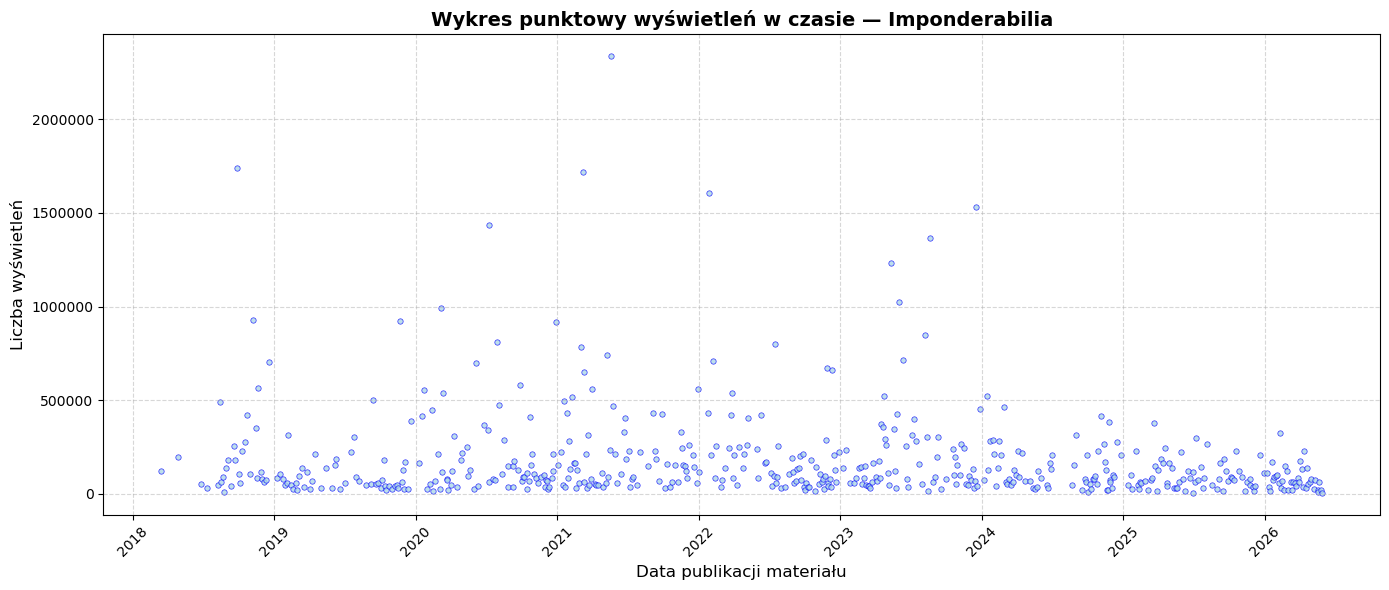

In [25]:
channel_info['published_at'] = pd.to_datetime(channel_info['published_at'])
channel_info = channel_info.sort_values('published_at')

plt.figure(figsize=(14, 6))

plt.scatter(channel_info['published_at'], channel_info['view_count'], alpha=0.8, s=15, color='lightblue', edgecolor='blue', linewidth=0.5)

plt.title(f'Wykres punktowy wyświetleń w czasie — {channel_name}', fontsize=14, fontweight='bold')
plt.xlabel('Data publikacji materiału', fontsize=12)
plt.ylabel('Liczba wyświetleń', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()